In [ ]:
import re
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    roc_curve,
    auc,
    precision_recall_curve,
)
from sklearn.preprocessing import label_binarize
import seaborn as sns

warnings.filterwarnings("ignore")

In [2]:
def strip_host(col: str) -> str:
    return re.sub(r"^\\\\[^\\]+\\", "", col).strip()


def load_pdh_csv(path: str) -> pd.DataFrame:
    df = pd.read_csv(path, low_memory=False)
    df.columns = [strip_host(c) if i > 0 else "ts" for i, c in enumerate(df.columns)]
    df = df.drop(columns=["ts"], errors="ignore")
    df = df.replace(" ", np.nan)
    return pd.to_numeric(df.stack(), errors="coerce").unstack()

In [3]:
NORMAL_FILES = [
    "data/cleaned_combined.csv",
]

CPU_COL  = "Processor_% Processor Time"
MEM_COL  = "Memory_Pages/sec"
IO_COL   = "Process_IO Data Bytes/sec"
IDLE_COL = "Processor_% Idle Time"

LABEL_COLS = {CPU_COL, MEM_COL, IO_COL, IDLE_COL}

FEATURE_COLS = [
    "Processor_% Privileged Time",
    "Processor_% User Time",
    "Processor_Interrupts/sec",
    "Processor_DPCs Queued/sec",
    "Process_IO Read Bytes/sec",
    "Process_IO Write Bytes/sec",
    "Process_IO Data Operations/sec",
    "Process_IO Read Operations/sec",
    "Process_Working Set",
    "Process_Working Set - Private",
    "Process_Page Faults/sec",
    "Process_Thread Count",
    "Memory_Page Faults/sec",
    "Memory_Demand Zero Faults/sec",
    "Memory_Available MBytes",
    "Memory_% Committed Bytes In Use",
    "Memory_Cache Faults/sec",
    "Memory_Transition Faults/sec",
]

In [4]:
def assign_load_state(df: pd.DataFrame) -> pd.Series:
    cpu = df[CPU_COL].fillna(0)
    mem = df[MEM_COL].fillna(0)
    io  = df[IO_COL].fillna(0)

    state = pd.Series("Active", index=df.index)
    state[cpu >= 30] = "Stressed"
    state[(mem > 200) & (io > 1e6)] = "Stressed"
    state[(cpu < 5) & (io < 5e4)] = "Idle"
    return state

In [5]:
class LoadStateClassifier:

    def __init__(self, max_depth: int = 4, min_samples_leaf: int = 30):
        self.max_depth = max_depth
        self.min_samples_leaf = min_samples_leaf
        self.dt = None
        self.le = LabelEncoder()
        self.feature_cols = None

    def fit(self, X: pd.DataFrame, y: pd.Series):
        self.feature_cols = list(X.columns)
        y_enc = self.le.fit_transform(y)
        self.dt = DecisionTreeClassifier(
            max_depth=self.max_depth,
            min_samples_leaf=self.min_samples_leaf,
            criterion="gini",
            random_state=42,
        )
        self.dt.fit(X, y_enc)
        return self

    def predict(self, X: pd.DataFrame) -> np.ndarray:
        return self.le.inverse_transform(self.dt.predict(X))

    def score(self, X: pd.DataFrame, y: pd.Series) -> float:
        return accuracy_score(y, self.predict(X))

    def report(self, X: pd.DataFrame, y: pd.Series):
        y_pred = self.predict(X)
        print("=" * 55)
        print("LOAD STATE CLASSIFIER — EVALUATION")
        print("=" * 55)
        print(classification_report(y, y_pred, target_names=self.le.classes_))
        print(f"Accuracy : {accuracy_score(y, y_pred):.4f}")
        short = [c.split("\\")[-1][:35] for c in self.feature_cols]
        print("\nDecision rules:")
        print(export_text(self.dt, feature_names=short))

    def predict_file(self, path: str) -> pd.DataFrame:
        df = load_pdh_csv(path)
        for col in self.feature_cols:
            if col not in df.columns:
                df[col] = 0.0
        X = df[self.feature_cols].fillna(0)
        labels = self.predict(X)
        return pd.DataFrame({"load_state": labels})

    def plot(self):
        fig, axes = plt.subplots(1, 2, figsize=(18, 7))
        short = [c.split("\\")[-1][:25] for c in self.feature_cols]
        plot_tree(
            self.dt,
            feature_names=short,
            class_names=self.le.classes_,
            filled=True, rounded=True, impurity=True,
            ax=axes[0], fontsize=8,
        )
        axes[0].set_title("Decision Tree — System Load State", fontsize=12)
        fi = pd.Series(self.dt.feature_importances_,
                       index=[c.split("\\")[-1] for c in self.feature_cols])
        fi = fi[fi > 0].sort_values()
        fi.plot(kind="barh", ax=axes[1], color="#7F77DD")
        axes[1].set_title("Feature Importances (Gini-based)")
        axes[1].set_xlabel("Importance")
        plt.tight_layout()
        plt.show()

    def plot_confusion(self, X: pd.DataFrame, y: pd.Series):
        y_pred = self.predict(X)
        cm = confusion_matrix(y, y_pred, labels=self.le.classes_)
        fig, ax = plt.subplots(figsize=(6, 5))
        sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                    xticklabels=self.le.classes_,
                    yticklabels=self.le.classes_, ax=ax)
        ax.set_xlabel("Predicted")
        ax.set_ylabel("Actual")
        ax.set_title("Confusion Matrix — Load State Classifier")
        plt.tight_layout()
        plt.show()


In [6]:
TREE_DEPTH   = 4

Loading cleaned dataset ...
Load state distribution:
load_state
Active      16564
Stressed     8438
Idle         4144

Training on 18 features (label columns excluded)
LOAD STATE CLASSIFIER — EVALUATION
              precision    recall  f1-score   support

      Active       0.94      0.95      0.94      4141
        Idle       0.99      0.98      0.98      1036
    Stressed       0.91      0.88      0.90      2110

    accuracy                           0.94      7287
   macro avg       0.94      0.94      0.94      7287
weighted avg       0.94      0.94      0.94      7287

Accuracy : 0.9366

Decision rules:
|--- Processor_Interrupts/sec <= 233.34
|   |--- Process_IO Read Bytes/sec <= 44579.57
|   |   |--- Processor_DPCs Queued/sec <= 103.53
|   |   |   |--- Process_IO Write Bytes/sec <= 23694.32
|   |   |   |   |--- class: 1
|   |   |   |--- Process_IO Write Bytes/sec >  23694.32
|   |   |   |   |--- class: 1
|   |   |--- Processor_DPCs Queued/sec >  103.53
|   |   |   |--- class: 

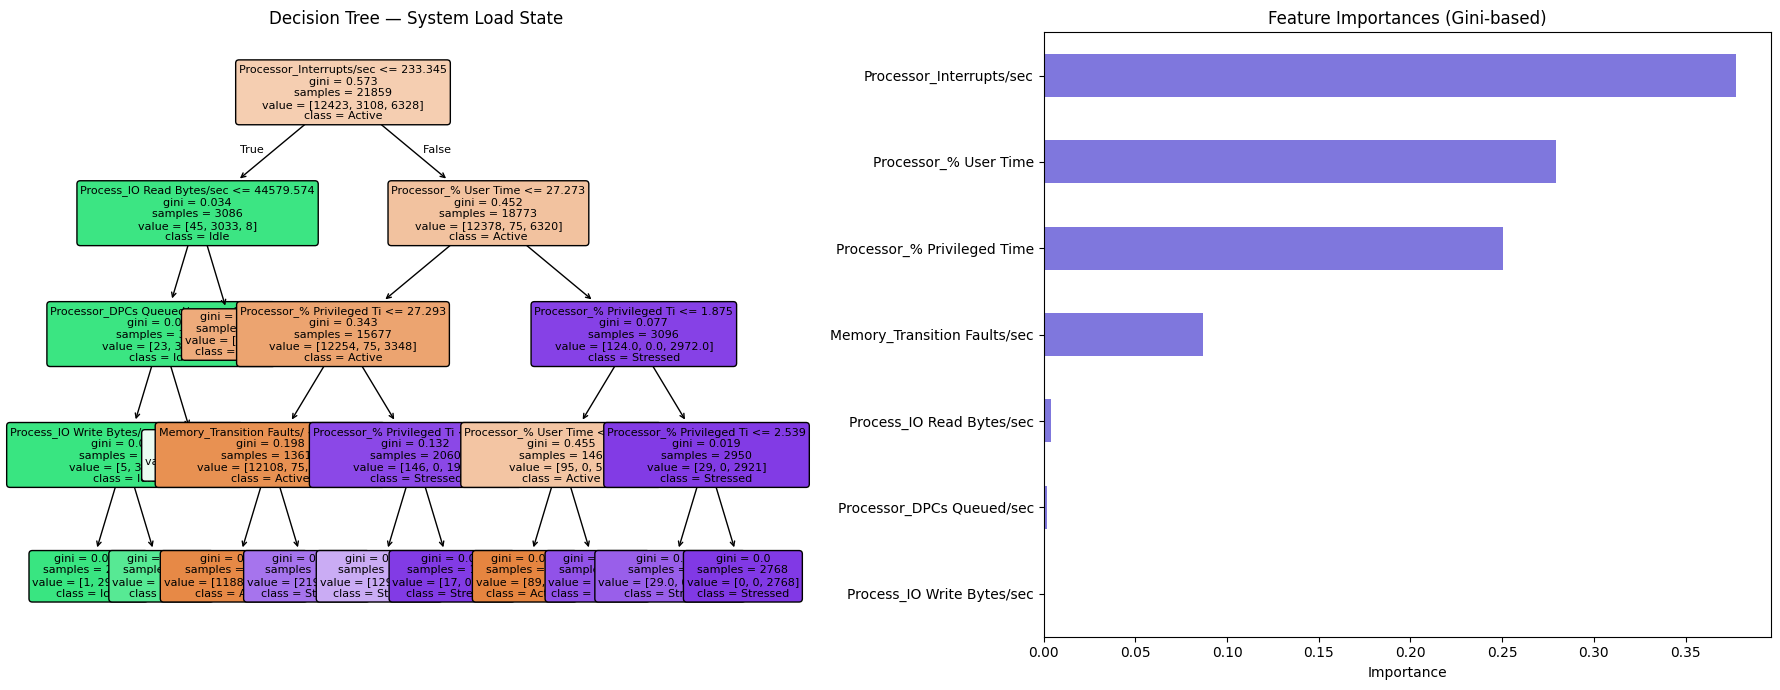

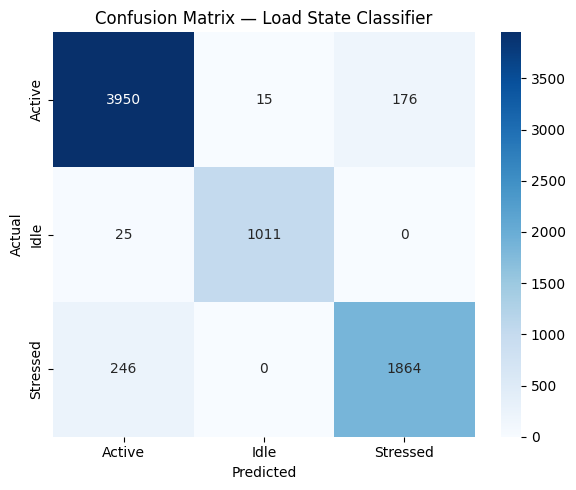

In [7]:
depth = TREE_DEPTH

print("Loading cleaned dataset ...")
data = pd.read_csv("data/cleaned_combined.csv", low_memory=False)
common = [
    c for c in data.columns
    if c not in ["timestamp", "os", "label", "source_file"]
]
data = data.dropna(thresh=int(0.2 * len(common)))

data["load_state"] = assign_load_state(data)
print("Load state distribution:")
print(data["load_state"].value_counts().to_string())

feat_cols = [c for c in FEATURE_COLS if c in common]
if not feat_cols:
    feat_cols = [c for c in common if c not in LABEL_COLS]
print(f"\nTraining on {len(feat_cols)} features (label columns excluded)")

X = data[feat_cols].fillna(0)
y = data["load_state"]

X_tr, X_te, y_tr, y_te = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

clf = LoadStateClassifier(max_depth=depth)
clf.fit(X_tr, y_tr)

clf.report(X_te, y_te)

clf.plot()
clf.plot_confusion(X_te, y_te)

In [ ]:
# Get probability predictions for ROC/PR curves
y_prob = clf.dt.predict_proba(X_te)
y_test_bin = label_binarize(y_te, classes=clf.le.classes_)
classes_ordered = clf.le.classes_
colors = ["#378ADD", "#1D9E75", "#E24B4A"]

# Plot ROC curves for each class (One-vs-Rest)
fig_roc, ax_roc = plt.subplots(figsize=(7, 6))
for i, (cls, color) in enumerate(zip(classes_ordered, colors)):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_prob[:, i])
    roc_auc = auc(fpr, tpr)
    ax_roc.plot(fpr, tpr, color=color, linewidth=2, label=f"{cls} (AUC = {roc_auc:.3f})")

ax_roc.plot([0, 1], [0, 1], "k--", linewidth=1)
ax_roc.set_xlabel("False Positive Rate")
ax_roc.set_ylabel("True Positive Rate")
ax_roc.set_title("One-vs-Rest ROC Curves — Decision Tree Classifier")
ax_roc.legend(loc="lower right")
ax_roc.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Plot Precision-Recall curves for each class
fig_pr, ax_pr = plt.subplots(figsize=(7, 6))
for i, (cls, color) in enumerate(zip(classes_ordered, colors)):
    precision, recall, _ = precision_recall_curve(y_test_bin[:, i], y_prob[:, i])
    avg_precision = np.mean(precision[:-1])  # Average precision (simplified)
    ax_pr.plot(recall, precision, color=color, linewidth=2, label=f"{cls} (AP = {avg_precision:.3f})")

ax_pr.set_xlabel("Recall")
ax_pr.set_ylabel("Precision")
ax_pr.set_title("One-vs-Rest Precision-Recall Curves — Decision Tree Classifier")
ax_pr.legend(loc="upper right")
ax_pr.grid(alpha=0.3)
ax_pr.set_xlim([0, 1])
ax_pr.set_ylim([0, 1])
plt.tight_layout()
plt.show()

## ROC and Precision-Recall Curves